In [1]:
!pip install pandas numpy matplotlib seaborn



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
import pandas as pd

df2= pd.read_csv("D:/Heart_Disease_Prediction/data/HeartDisease.csv")
df=pd.read_csv("D:/Heart_Disease_Prediction/data/UCI_Heart_Disease_Dataset_Combined.csv")
print("Dataset 1 Columns:")
print(df.columns)

print("\nDataset 2 Columns:")
print(df2.columns)
# df.head()
# df.shape
# df.columns
# df.info()
# df.isnull().sum()

Dataset 1 Columns:
Index(['Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')

Dataset 2 Columns:
Index(['ID', 'Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalach', 'exang', 'oldpeak', 'target', 'Place'],
      dtype='object')


In [4]:
df2 = df2.drop(columns=["ID", "Place"], errors="ignore")

df2.columns

Index(['Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')

In [5]:
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)
df2["target"] = df2["target"].apply(lambda x: 0 if x == 0 else 1)

In [6]:
print(df["target"].unique())
print(df2["target"].unique())

[0 1]
[0 1]


In [7]:
df.head()
df2.head()

,Age,Sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,target
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


In [8]:
print("DF columns:", df.columns)
print("DF2 columns:", df2.columns)

DF columns: Index(['Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')
DF2 columns: Index(['Age', 'Sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')


In [9]:
df = df.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "ChestPainType": "cp",
    "RestingBP": "trestbps",
    "Cholesterol": "chol",
    "FastingBS": "fbs",
    "RestingECG": "restecg",
    "MaxHR": "thalach",
    "ExerciseAngina": "exang",
    "Oldpeak": "oldpeak",
    "HeartDisease": "target"
})

In [10]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')

In [11]:
df2 = df2.rename(columns={
    "Age": "age",
    "Sex": "sex",
    "cp": "cp",
    "trestbps": "trestbps",
    "chol": "chol",
    "fbs": "fbs",
    "restecg": "restecg",
    "thalach": "thalach",
    "exang": "exang",
    "oldpeak": "oldpeak",
    "num": "target"
})

In [12]:
df2.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'target'],
      dtype='object')

In [13]:
df = df[["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","target"]]
df2 = df2[["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","target"]]

In [14]:
combined_df = pd.concat([df, df2], ignore_index=True)

combined_df.shape

(3400, 11)

In [15]:
combined_df["target"].value_counts()

target
1    1824
0    1576
Name: count, dtype: int64

In [16]:
combined_df.isnull().sum()

age          0
sex          0
cp           0
trestbps    33
chol        26
fbs         54
restecg      2
thalach     33
exang       33
oldpeak     36
target       0
dtype: int64

In [17]:
for col in combined_df.columns:
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())

In [18]:
X = combined_df.drop("target", axis=1)
y = combined_df["target"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [22]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8044117647058824
ROC-AUC: 0.892054794520548

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.80      0.79       315
           1       0.82      0.81      0.82       365

    accuracy                           0.80       680
   macro avg       0.80      0.80      0.80       680
weighted avg       0.80      0.80      0.80       680



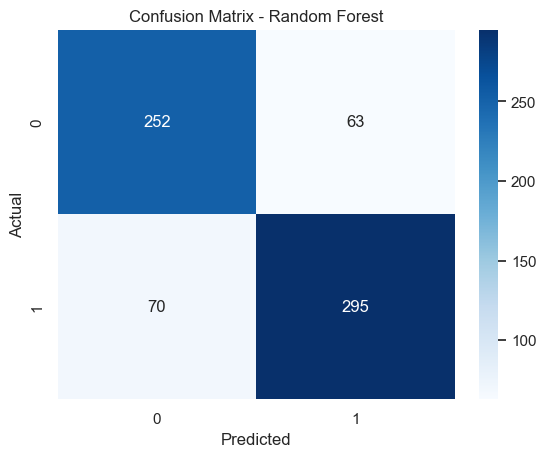

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std Deviation:", cv_scores.std())


Cross-Validation ROC-AUC Scores: [0.83243497 0.88376604 0.94697108 0.70400522 0.78260491]
Mean ROC-AUC: 0.8299564438990483
Std Deviation: 0.0833065652504843


In [26]:
rf_stable = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,              # reduced
    min_samples_leaf=10,      # increased
    min_samples_split=10,
    class_weight="balanced",
    random_state=42
)

In [27]:
rf_stable.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [28]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_pred_stable = rf_stable.predict(X_test)
y_prob_stable = rf_stable.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_stable))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stable))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stable))

Accuracy: 0.7808823529411765
ROC-AUC: 0.8595172863666014

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.76      0.76       315
           1       0.79      0.80      0.80       365

    accuracy                           0.78       680
   macro avg       0.78      0.78      0.78       680
weighted avg       0.78      0.78      0.78       680



In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_stable = cross_val_score(
    rf_stable,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

print("Stratified CV Scores:", cv_scores_stable)
print("Mean ROC-AUC:", cv_scores_stable.mean())
print("Std Dev:", cv_scores_stable.std())

Stratified CV Scores: [0.87934692 0.8686671  0.8704327  0.85079365 0.86237878]
Mean ROC-AUC: 0.8663238303996064
Std Dev: 0.009473378520867373


In [30]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_stable)

# Print some threshold-recall pairs
for i in range(0, len(thresholds), max(1, len(thresholds)//10)):
    print(f"Threshold: {thresholds[i]:.2f}, Recall: {recall[i]:.2f}, Precision: {precision[i]:.2f}")

Threshold: 0.07, Recall: 1.00, Precision: 0.54
Threshold: 0.20, Recall: 0.99, Precision: 0.59
Threshold: 0.31, Recall: 0.97, Precision: 0.65
Threshold: 0.37, Recall: 0.92, Precision: 0.71
Threshold: 0.45, Recall: 0.84, Precision: 0.76
Threshold: 0.54, Recall: 0.76, Precision: 0.83
Threshold: 0.62, Recall: 0.61, Precision: 0.85
Threshold: 0.69, Recall: 0.47, Precision: 0.88
Threshold: 0.76, Recall: 0.32, Precision: 0.91
Threshold: 0.84, Recall: 0.16, Precision: 0.94


In [31]:
custom_threshold = 0.37

y_pred_custom = (y_prob_stable >= custom_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom))

cm_custom = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix:\n", cm_custom)

              precision    recall  f1-score   support

           0       0.85      0.58      0.69       315
           1       0.72      0.92      0.80       365

    accuracy                           0.76       680
   macro avg       0.78      0.75      0.75       680
weighted avg       0.78      0.76      0.75       680

Confusion Matrix:
 [[182 133]
 [ 31 334]]


In [32]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    rf_stable,
    method='sigmoid',   # Platt scaling
    cv=5
)

calibrated_rf.fit(X_train, y_train)

y_prob_calibrated = calibrated_rf.predict_proba(X_test)[:,1]

print("Calibrated ROC-AUC:", roc_auc_score(y_test, y_prob_calibrated))

Calibrated ROC-AUC: 0.855959991302457


In [33]:
precision_c, recall_c, thresholds_c = precision_recall_curve(y_test, y_prob_calibrated)

for i in range(0, len(thresholds_c), max(1, len(thresholds_c)//10)):
    print(f"Threshold: {thresholds_c[i]:.2f}, Recall: {recall_c[i]:.2f}, Precision: {precision_c[i]:.2f}")

Threshold: 0.04, Recall: 1.00, Precision: 0.54
Threshold: 0.11, Recall: 0.99, Precision: 0.59
Threshold: 0.21, Recall: 0.97, Precision: 0.66
Threshold: 0.28, Recall: 0.92, Precision: 0.71
Threshold: 0.44, Recall: 0.83, Precision: 0.76
Threshold: 0.62, Recall: 0.75, Precision: 0.82
Threshold: 0.74, Recall: 0.61, Precision: 0.85
Threshold: 0.83, Recall: 0.47, Precision: 0.88
Threshold: 0.89, Recall: 0.32, Precision: 0.90
Threshold: 0.94, Recall: 0.16, Precision: 0.94


In [44]:
final_threshold = 0.45

y_final = (y_prob_calibrated >= final_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_final))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74       315
           1       0.77      0.83      0.80       365

    accuracy                           0.77       680
   macro avg       0.77      0.77      0.77       680
weighted avg       0.77      0.77      0.77       680

Confusion Matrix:
 [[222  93]
 [ 62 303]]


In [45]:
import pickle

# Save calibrated model
with open("../app/model/calibrated_model.pkl", "wb") as f:
    pickle.dump(calibrated_rf, f)

# Save threshold
with open("../app/model/threshold.pkl", "wb") as f:
    pickle.dump(0.28, f)

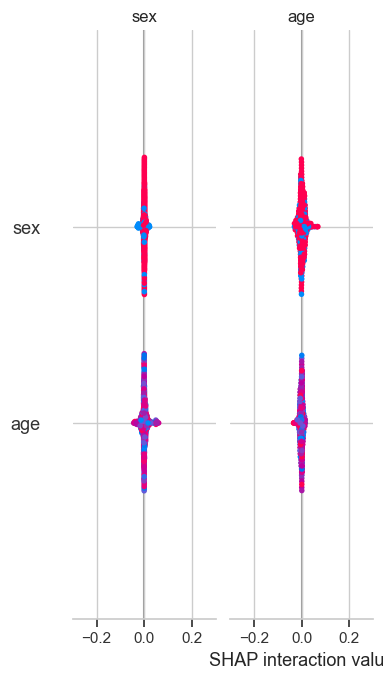

In [46]:
import shap

explainer = shap.Explainer(rf_stable)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [47]:
print(shap_values.values.shape)

(680, 10, 2)


In [48]:
import numpy as np
import pandas as pd

# Take only class 1 (disease)
shap_vals = shap_values.values[:, :, 1]

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": np.abs(shap_vals).mean(axis=0)
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
2,cp,0.126236
3,trestbps,0.050943
4,chol,0.050554
6,restecg,0.045415
5,fbs,0.029745
9,oldpeak,0.028074
8,exang,0.025378
7,thalach,0.014876
0,age,0.004232
1,sex,0.003415


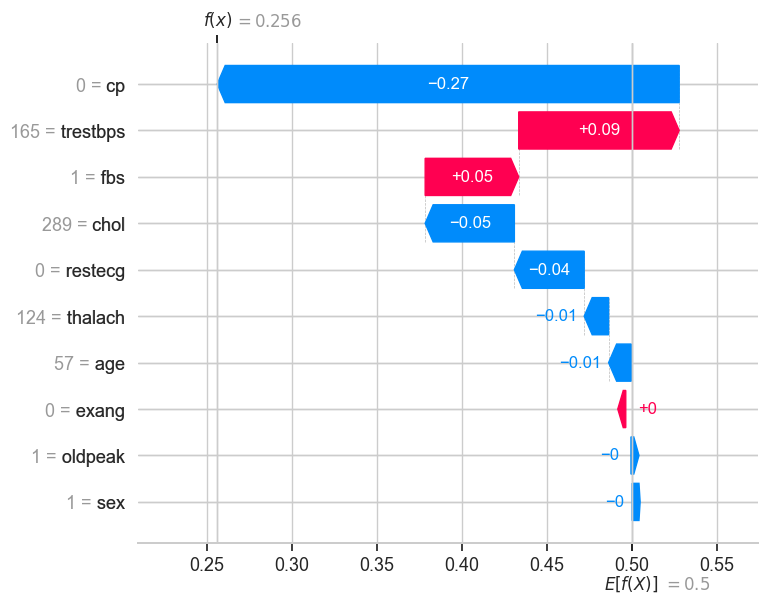

In [49]:
shap.plots.waterfall(shap_values[0][:, 1])